<a href="https://colab.research.google.com/github/tylerjohnbecker/Nonlinear_and_Data_Driven_Estimation/blob/main/BouncingBall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas
from scipy.integrate import odeint

In [ ]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/florisvb/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package , function_name)
            return function
        else:
            return package

plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')

In [ ]:
try:
    import casadi
except:
    !pip install casadi
    import casadi

try:
    import do_mpc
except:
    !pip install do_mpc
    import do_mpc

try:
    import pybounds
except:
    !pip install pybounds
    import pybounds

# For now keeping known values for estimated parameters

In [ ]:
m = 1
r = .1
e = .6
mu = .6
delta_t = .2
Im = 1
g=-9.81

In [ ]:
def f_in_air(x_vec, u_vec, m=m, g=g, Im=Im, r=r, e=e, mu=mu):
    """
    Continuous time dynamics function for the system shown in the equation.

    Parameters:
    x_vec : array-like, shape (7,)
        State vector [θ, θ̇, x, ẋ, z, ż, k]
    u_vec : array-like, shape (2,)
        Control vector [j1, j2]
    L : float, default 0.5
        drone arm length
    m : float, default 1.0
        drone mass
    g : float, default 9.81
        Gravitational acceleration

    Returns:
    x_dot : numpy array, shape (7,)
        Time derivative of state vector
    """

    # Extract state variables
    x = x_vec[0]
    x_dot = x_vec[1]
    z = x_vec[2]
    z_dot = x_vec[3]
    theta = x_vec[4]
    theta_dot = x_vec[5]

    # Extract control inputs
    f_x = u_vec[0]
    f_z = u_vec[1]
    tor = u_vec[2]

    # f0 component: drift dynamics (no controls)
    f0_contribution = np.array([ x_dot,
                                 0,
                                 z_dot,
                                 g,
                                 theta_dot,
                                 0])

    # f1 component: multiplied by control u1
    f1_contribution = f_x * np.array([0,
                                     1 / m,
                                     0,
                                     0,
                                     0,
                                     0])

    # f2 component: multiplied by control u2
    f2_contribution = f_z * np.array([0,
                                     0,
                                     0,
                                     1 / m ,
                                     0,
                                     0])

    # f3 component: multiplied by control u3
    f3_contribution = tor * np.array([0,
                                     0,
                                     0,
                                     0,
                                     0,
                                     1 / Im])

    # combined dynamics
    x_dot_vec = f0_contribution + f1_contribution + f2_contribution + f3_contribution

    return x_dot_vec

In [ ]:
def f_impact(x_vec, u_vec, m=m, g=g, Im=Im, r=r, e=e, mu=mu):
    """
    Continuous time dynamics function for the system shown in the equation.

    Parameters:
    x_vec : array-like, shape (7,)
        State vector [θ, θ̇, x, ẋ, z, ż, k]
    u_vec : array-like, shape (2,)
        Control vector [j1, j2]
    L : float, default 0.5
        drone arm length
    m : float, default 1.0
        drone mass
    g : float, default 9.81
        Gravitational acceleration

    Returns:
    x_dot : numpy array, shape (7,)
        Time derivative of state vector
    """

    # Extract state variables
    x = x_vec[0]
    x_dot = x_vec[1]
    z = x_vec[2]
    z_dot = x_vec[3]
    theta = x_vec[4]
    theta_dot = x_vec[5]

    # Extract control inputs
    f_x = u_vec[0]
    f_z = u_vec[1]
    tor = u_vec[2]

    theta_dot2 = ( -r * mu / Im ) * ( m * g )

    # f0 component: drift dynamics (no controls)
    f0_contribution = np.array([ x_dot,
                                 - np.sign(x_dot) * np.abs( mu * g ) + ( - theta_dot * r / delta_t ) ,
                                 - z_dot * e,
                                 - z_dot * ( 1 + e ) / delta_t,
                                 theta_dot,
                                 theta_dot2])

    # f1 component: multiplied by control u1
    f1_contribution = f_x * np.array([0,
                                     1 / m,
                                     0,
                                     0,
                                     0,
                                     0])

    # f2 component: multiplied by control u2
    f2_contribution = f_z * np.array([0,
                                     0,
                                     0,
                                     1 / m,
                                     0,
                                     0])

    # f3 component: multiplied by control u3
    f3_contribution = tor * np.array([0,
                                     0,
                                     0,
                                     0,
                                     0,
                                     1 / Im])

    # combined dynamics
    x_dot_vec = f0_contribution + f1_contribution + f2_contribution + f3_contribution

    return x_dot_vec

In [ ]:
state = True

def f (x_vec, u_vec):
    global state

    # if x_vec[2] < .1 and state:
    #     state = False
    #     return f_impact(x_vec, u_vec)

    # state = True
    z = x_vec[2]

    return (np.ceil( 1 - z / 10) - 1) * f_impact(x_vec, u_vec) + np.ceil(z / 1000000) * f_in_air(x_vec, u_vec)

In [ ]:
def f_ode(x_vec, tsim, u_func, f):
    '''
    Wrap dynamics function so it can be used with odeint.

    Parameters:
    x_vec : array-like, shape (7,)
        State vector
    tsim : float
        Current time step
    u_func: function
        Control function
    f: function
        Continuous time dynamics function

    Returns:
    x_dot_vec : numpy array, shape (7,)
        Time derivative of state vector
    '''
    u_vec = u_func(x_vec, tsim)
    x_dot_vec = f(x_vec, u_vec)
    return x_dot_vec

In [ ]:
def u_func(x_vec, tsim, m=m, g=g, r=r, Im=Im, e=e, mu=mu):
    '''
    Simple controller that moves the drone right, so I can observe it bouncing.
    '''
    x_dot_desired = 1
    x_dot = x_vec[1]

    err_x = max( 0, x_dot_desired - x_dot )

    ctrl_x = 10 * err_x

    theta_dot_desired = -4
    theta_dot = x_vec[4]

    err_theta = theta_dot_desired - theta_dot

    ctrl_theta = 10 * err_theta

    return [0, 0, ctrl_theta]

In [ ]:
delta_t = .05
tsim = np.arange(0, 5.0, step=delta_t)

In [ ]:
x0 = np.array([0, 1.0, 10.0, 0, 0, 0.0])

In [ ]:
result = odeint(f_ode, x0, tsim, args=(u_func, f))

In [ ]:
def ground_event(t, x_vector):
    """
    Detects when the ball hits the ground (y = 0).
    The solver will find the root (t) where this function becomes zero.
    """
    return x_vector[2] # z

ground_event.terminal = True
ground_event.direction = -1

In [ ]:
initial_state = x0
events = []

current_time = tsim[0]
current_state = initial_state
sol = [initial_state]

for i in range(1, len(tsim)):
    next_time = tsim[i]

    # Integrate for a small step
    sol.append(odeint(f_ode, current_state, [current_time, next_time], args=(u_func, f))[-1])

    # Check for event
    event_val_prev = ground_event(current_time, current_state)

    current_state = sol[-1]
    current_time = next_time

    if i > 0:
        event_val_curr = ground_event(next_time, sol[-1])

        if event_val_prev * event_val_curr < 0:
            events.append((next_time, sol[-1][0]))

            # update current state to reflect the change from impact
            current_state += f_impact(current_state, [0, 0, 0]) * delta_t

    if current_state[2] < 0:
        current_state[2] = 0


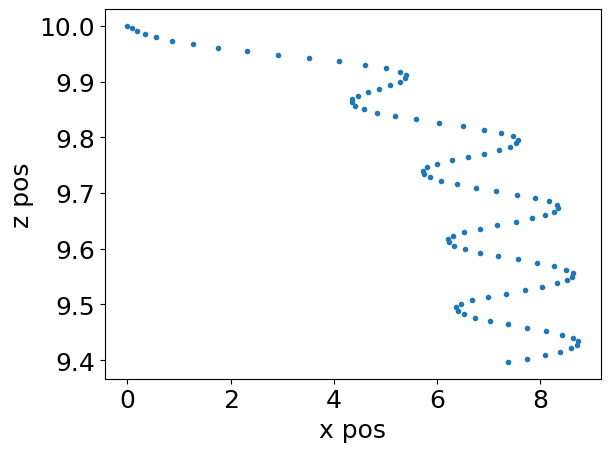

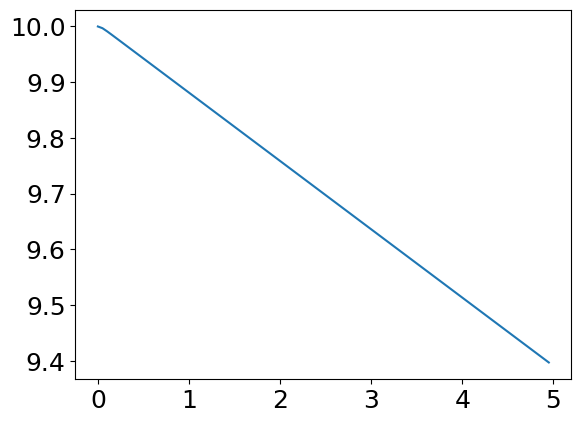

In [ ]:
sol = np.array(sol)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(result[:, 0], result[:, 2], '.')
ax.set_xlabel('x pos')
ax.set_ylabel('z pos')


fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
ax2.plot(tsim, result[:,2])

In [ ]:
def h(x_vec, u_vec):
    return [x_vec[0], x_vec[2], x_vec[4]]

In [ ]:
import pybounds

In [ ]:
state_names = [ 'x', 'x_dot', 'z', 'z_dot', 'theta', 'theta_dot']
input_names = ['u1', 'u2', 'u3']
measurement_names = ['x', 'z', 'theta']

In [ ]:
simulator = pybounds.Simulator(f, h, dt=delta_t, state_names=state_names,
                               input_names=input_names, measurement_names=measurement_names, mpc_horizon=10)

In [ ]:
# First define the set-point(s) to follow
tsim = np.arange(0, 8.0, step=delta_t)
NA = np.zeros_like(tsim)
setpoint = {'theta': NA,
            'theta_dot': NA,
            'x': tsim,  # ground speed changes as a sinusoid
            'x_dot': NA,
            'z': np.abs(np.cos(tsim)), # altitude also oscillates
            'z_dot': NA,
           }

In [ ]:
# Update the simulator set-point
simulator.update_dict(setpoint, name='setpoint')

In [ ]:
# Define MPC cost function: penalize the squared error between the setpoint for g and the true g
cost_x = (simulator.model.x['x'] - simulator.model.tvp['x_set']) ** 2
cost_z = (simulator.model.x['z'] - simulator.model.tvp['z_set']) ** 2
cost = cost_x + cost_z #+ cost_k

In [ ]:
# Set cost function
simulator.mpc.set_objective(mterm=cost, lterm=cost)  # objective function

# Set input penalty: make this small for accurate state tracking
simulator.mpc.set_rterm(u1=1e-4, u2=1e-4, u3=1e-4)

In [ ]:
simulator.mpc.bounds['lower', '_x', 'z'] = 0.0

In [ ]:
# Run simulation using MPC
t_sim, x_sim, u_sim, y_sim = simulator.simulate(x0=None, u=None, mpc=True, return_full_output=True)